# 05 - Train Classifiers

Trains two fast neural network classifiers from scratch (`src/ml_from_scratch.py`) on catalog embeddings and bootstrapped teacher labels:
- **Category Classifier**: Maps 1024-d text embeddings to 1 of 4 categories.
- **Emotion Classifier**: Maps 1024-d text embeddings to 1 of 4 emotions.

---

### Evaluation & Optimization
- **80/20 Stratified Split**: Evaluates against majority-class baselines.
- **Class-Balancing Strategies**: Tests unweighted, inverse class weighting, and training-set oversampling, retaining the best validation macro-F1 model.
- **Export**: Computes target precision/recall thresholds, confusion matrices, and ROC-AUC curves, exporting weights and `models/metrics.json`.


In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
from datetime import datetime

import chromadb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

from app.config import (
    CATALOG_CSV,
    CATEGORIES,
    CATEGORY_MODEL_PATH,
    DATA_DIR,
    EMBEDDING_MODEL_NAME,
    EMOTION_MODEL_PATH,
    EMOTION_PROFILE_PATH,
    EMOTIONS,
    LOGS_DIR,
    METRICS_PATH,
    MODELS_DIR,
    VECTOR_STORE_COLLECTION,
    VECTOR_STORE_DIR,
    get_logger,
)
from src.ml_from_scratch import NeuralNetwork

logger = get_logger("train_classifiers")

RANDOM_SEED = 42
MODELS_DIR.mkdir(parents=True, exist_ok=True)

catalog = pd.read_csv(CATALOG_CSV, dtype={"isbn13": "string"})
logger.info("Loaded catalog: %d rows, %d columns", *catalog.shape)


2026-08-17 19:44:58 | INFO    | booklens.train_classifiers | Loaded catalog: 22568 rows, 19 columns


## 1. Load Catalog Embeddings

Fetches precomputed embeddings from Chroma, aligned to catalog row positions.


In [2]:
chroma_client = chromadb.PersistentClient(path=str(VECTOR_STORE_DIR))
collection = chroma_client.get_collection(VECTOR_STORE_COLLECTION)

raw = collection.get(include=["embeddings"])
embeddings_by_row_id = {int(row_id): embedding for row_id, embedding in zip(raw["ids"], raw["embeddings"])}

assert set(embeddings_by_row_id.keys()) == set(range(len(catalog))), (
    "Vector store row ids don't match the current catalog - re-run notebook 03 first."
)

all_embeddings = np.array([embeddings_by_row_id[i] for i in range(len(catalog))])
logger.info("Loaded %d embeddings, shape %s", len(all_embeddings), all_embeddings.shape)


2026-08-17 19:45:00 | INFO    | booklens.train_classifiers | Loaded 22568 embeddings, shape (22568, 1024)


## 2. Model Training & Evaluation Routine

Trains candidate NeuralNetwork models across three balance strategies (unweighted, balanced weights, oversampling) and selects the best validation macro-F1 model.


In [3]:
def oversample_to_balance(X: np.ndarray, y: np.ndarray, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """
    Duplicate minority-class rows (with replacement) until every class in
    `y` has as many rows as the largest class. Only ever applied to a
    training split - never to validation data, which must stay a faithful
    sample of the real, uneven distribution.
    """
    class_labels, class_counts = np.unique(y, return_counts=True)
    target_count = int(class_counts.max())

    balanced_indices = []
    for label, count in zip(class_labels, class_counts):
        class_indices = np.where(y == label)[0]
        balanced_indices.append(class_indices)
        if count < target_count:
            extra_indices = rng.choice(class_indices, size=target_count - count, replace=True)
            balanced_indices.append(extra_indices)

    balanced_indices = np.concatenate(balanced_indices)
    rng.shuffle(balanced_indices)
    return X[balanced_indices], y[balanced_indices]


def _roc_metrics(y_val: np.ndarray, val_probabilities: np.ndarray, label_names: list[str], curve_points: int = 21) -> dict:
    """
    Per-class ROC-AUC + a compact (interpolated) ROC curve, plus the
    macro-average AUC across all classes (one-vs-rest). Curves are
    interpolated onto a fixed `curve_points`-point false-positive-rate
    grid so metrics.json stays small regardless of validation-set size.
    """
    fpr_grid = np.linspace(0.0, 1.0, curve_points)
    per_class = {}
    for class_index, label in enumerate(label_names):
        y_true_binary = (y_val == class_index).astype(int)
        if y_true_binary.sum() == 0 or y_true_binary.sum() == len(y_true_binary):
            # A class absent from (or covering all of) this validation split
            # has an undefined ROC curve - skip rather than report a fake number.
            continue
        class_auc = roc_auc_score(y_true_binary, val_probabilities[:, class_index])
        fpr, tpr, _ = roc_curve(y_true_binary, val_probabilities[:, class_index])
        per_class[label] = {
            "auc": float(class_auc),
            "fpr": fpr_grid.tolist(),
            "tpr": np.interp(fpr_grid, fpr, tpr).tolist(),
        }

    macro_auc = float(roc_auc_score(y_val, val_probabilities, multi_class="ovr", average="macro"))
    return {"macro_auc": macro_auc, "per_class": per_class}


def train_and_evaluate_task(task_name, labels_series, label_names, embeddings, hidden_dim=64, epochs=100):
    """
    Train one NeuralNetwork for `task_name`, trying three training
    strategies - unweighted, class_weight="balanced", and training-set
    oversampling - and keeping whichever scores highest validation
    macro-F1.

    Returns a dict with the trained model, the validation split, and every
    metric this evaluation reports on (accuracy, macro-F1, per-class and
    aggregate precision/recall/F1, and per-class + macro ROC-AUC).
    """
    label_to_index = {name: i for i, name in enumerate(label_names)}
    y = labels_series.map(label_to_index).to_numpy()

    X_train, X_val, y_train, y_val, train_idx, val_idx = train_test_split(
        embeddings, y, np.arange(len(y)),
        test_size=0.2, random_state=RANDOM_SEED, stratify=y,
    )

    rng = np.random.default_rng(RANDOM_SEED)
    candidates = {}
    for strategy in ("unweighted", "balanced", "oversampled"):
        if strategy == "oversampled":
            X_fit, y_fit = oversample_to_balance(X_train, y_train, rng)
            class_weight = None
        else:
            X_fit, y_fit = X_train, y_train
            class_weight = "balanced" if strategy == "balanced" else None

        model = NeuralNetwork(input_dim=embeddings.shape[1], hidden_dim=hidden_dim, output_dim=len(label_names), seed=RANDOM_SEED)
        history = model.fit(
            X_fit, y_fit, X_val, y_val,
            epochs=epochs, batch_size=64, learning_rate=0.05,
            class_weight=class_weight, seed=RANDOM_SEED, logger=logger, log_every=20,
        )
        val_predictions = model.predict(X_val)
        macro_f1 = f1_score(y_val, val_predictions, average="macro")
        candidates[strategy] = {"model": model, "history": history, "macro_f1": macro_f1, "n_training_rows": len(X_fit)}
        logger.info(
            "[%s] strategy=%s (n_train=%d) -> val accuracy=%.4f, macro_f1=%.4f",
            task_name, strategy, len(X_fit), history["best_val_accuracy"], macro_f1,
        )

    best_strategy = max(candidates, key=lambda s: candidates[s]["macro_f1"])
    logger.info("[%s] keeping strategy=%s (higher validation macro-F1)", task_name, best_strategy)
    best = candidates[best_strategy]
    model = best["model"]

    val_probabilities = model.predict_proba(X_val)
    val_predictions = np.argmax(val_probabilities, axis=1)
    val_confidences = val_probabilities[np.arange(len(val_predictions)), val_predictions]
    is_correct = (val_predictions == y_val)

    majority_class = np.bincount(y_train).argmax()
    majority_predictions = np.full_like(y_val, majority_class)

    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        y_val, val_predictions, labels=range(len(label_names)), zero_division=0,
    )
    per_class_prf = {
        label_names[i]: {
            "precision": float(precision_per_class[i]),
            "recall": float(recall_per_class[i]),
            "f1": float(f1_per_class[i]),
            "support": int(support_per_class[i]),
        }
        for i in range(len(label_names))
    }
    precision_macro, recall_macro, f1_macro_check, _ = precision_recall_fscore_support(
        y_val, val_predictions, average="macro", zero_division=0,
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_val, val_predictions, average="weighted", zero_division=0,
    )
    roc = _roc_metrics(y_val, val_probabilities, label_names)

    return {
        "model": model,
        "training_strategy": best_strategy,
        "class_weight": "balanced" if best_strategy == "balanced" else None,
        "oversampled": best_strategy == "oversampled",
        "n_training_rows": best["n_training_rows"],
        "label_names": label_names,
        "val_idx": val_idx,
        "y_val": y_val,
        "val_predictions": val_predictions,
        "val_confidences": val_confidences,
        "is_correct": is_correct,
        "accuracy": accuracy_score(y_val, val_predictions),
        "macro_f1": f1_score(y_val, val_predictions, average="macro"),
        "majority_baseline_accuracy": accuracy_score(y_val, majority_predictions),
        "majority_baseline_macro_f1": f1_score(y_val, majority_predictions, average="macro"),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
        "per_class_prf": per_class_prf,
        "roc_auc_macro": roc["macro_auc"],
        "roc_per_class": roc["per_class"],
    }


## 3. Train Category Classifier

Fits and evaluates the category classifier on 1024-d embeddings.


In [4]:
category_result = train_and_evaluate_task(
    "category", catalog["category"], CATEGORIES, all_embeddings, hidden_dim=256, epochs=200,
)

logger.info(
    "Category - NN: accuracy=%.4f, macro_f1=%.4f | majority baseline: accuracy=%.4f, macro_f1=%.4f",
    category_result["accuracy"], category_result["macro_f1"],
    category_result["majority_baseline_accuracy"], category_result["majority_baseline_macro_f1"],
)


2026-08-17 19:45:03 | INFO    | booklens.train_classifiers | epoch 20/200 - val_accuracy=0.8793 (best=0.8872)
2026-08-17 19:45:07 | INFO    | booklens.train_classifiers | epoch 40/200 - val_accuracy=0.8759 (best=0.8923)
2026-08-17 19:45:10 | INFO    | booklens.train_classifiers | epoch 60/200 - val_accuracy=0.8784 (best=0.8963)
2026-08-17 19:45:13 | INFO    | booklens.train_classifiers | epoch 80/200 - val_accuracy=0.8970 (best=0.8990)
2026-08-17 19:45:16 | INFO    | booklens.train_classifiers | epoch 100/200 - val_accuracy=0.7842 (best=0.8994)
2026-08-17 19:45:19 | INFO    | booklens.train_classifiers | epoch 120/200 - val_accuracy=0.8932 (best=0.8996)
2026-08-17 19:45:22 | INFO    | booklens.train_classifiers | epoch 140/200 - val_accuracy=0.8946 (best=0.8996)
2026-08-17 19:45:25 | INFO    | booklens.train_classifiers | epoch 160/200 - val_accuracy=0.8799 (best=0.8996)
2026-08-17 19:45:28 | INFO    | booklens.train_classifiers | epoch 180/200 - val_accuracy=0.8855 (best=0.9003)
2026-

## 4. Train Emotion Classifier

Fits and evaluates the emotion classifier across the 4 target emotion labels.


In [5]:
emotion_result = train_and_evaluate_task("emotion", catalog["emotion"], EMOTIONS, all_embeddings)

logger.info(
    "Emotion - NN: accuracy=%.4f, macro_f1=%.4f | majority baseline: accuracy=%.4f, macro_f1=%.4f",
    emotion_result["accuracy"], emotion_result["macro_f1"],
    emotion_result["majority_baseline_accuracy"], emotion_result["majority_baseline_macro_f1"],
)


2026-08-17 19:46:59 | INFO    | booklens.train_classifiers | epoch 20/100 - val_accuracy=0.7466 (best=0.7481)
2026-08-17 19:47:00 | INFO    | booklens.train_classifiers | epoch 40/100 - val_accuracy=0.7669 (best=0.7669)
2026-08-17 19:47:01 | INFO    | booklens.train_classifiers | epoch 60/100 - val_accuracy=0.7588 (best=0.7760)
2026-08-17 19:47:02 | INFO    | booklens.train_classifiers | epoch 80/100 - val_accuracy=0.7732 (best=0.7787)
2026-08-17 19:47:03 | INFO    | booklens.train_classifiers | epoch 100/100 - val_accuracy=0.7492 (best=0.7809)
2026-08-17 19:47:03 | INFO    | booklens.train_classifiers | [emotion] strategy=unweighted (n_train=18054) -> val accuracy=0.7809, macro_f1=0.5843
2026-08-17 19:47:04 | INFO    | booklens.train_classifiers | epoch 20/100 - val_accuracy=0.6992 (best=0.6992)
2026-08-17 19:47:05 | INFO    | booklens.train_classifiers | epoch 40/100 - val_accuracy=0.6921 (best=0.7432)
2026-08-17 19:47:06 | INFO    | booklens.train_classifiers | epoch 60/100 - val_ac

## 5. Confusion Matrices

Plots validation confusion matrices for both classification tasks.


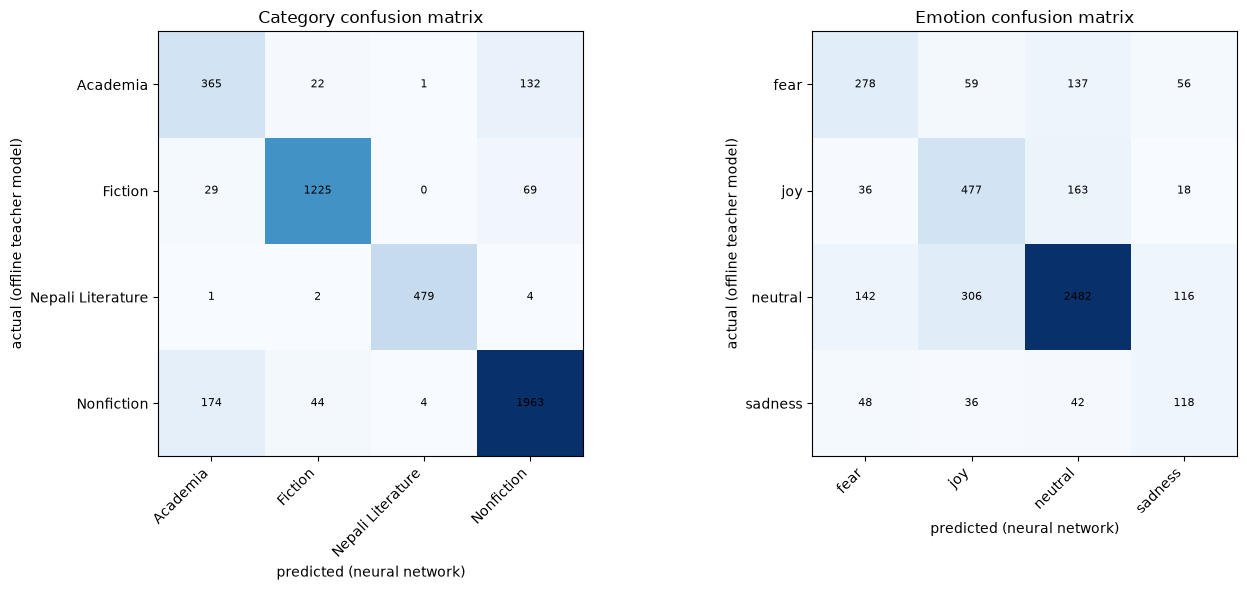

In [6]:
category_confusion = confusion_matrix(category_result["y_val"], category_result["val_predictions"], labels=range(len(CATEGORIES)))
emotion_confusion = confusion_matrix(emotion_result["y_val"], emotion_result["val_predictions"], labels=range(len(EMOTIONS)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, matrix, label_names, title in (
    (axes[0], category_confusion, CATEGORIES, "Category"),
    (axes[1], emotion_confusion, EMOTIONS, "Emotion"),
):
    ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(range(len(label_names)), label_names, rotation=45, ha="right")
    ax.set_yticks(range(len(label_names)), label_names)
    ax.set_xlabel("predicted (neural network)")
    ax.set_ylabel("actual (offline teacher model)")
    ax.set_title(f"{title} confusion matrix")
    for i in range(len(label_names)):
        for j in range(len(label_names)):
            ax.text(j, i, matrix[i, j], ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


## 6. Confidence Thresholds

Computes confidence thresholds required to reach target precision on held-out validation data.


In [7]:
def find_confidence_threshold(confidences, is_correct, target_precision=0.90, step=0.01):
    """Lowest confidence threshold clearing `target_precision`, swept in `step` increments."""
    best_operating_point = None
    for threshold in np.arange(0.0, 1.0 + step, step):
        kept = confidences >= threshold
        if kept.sum() == 0:
            continue
        precision = is_correct[kept].mean()
        best_operating_point = {
            "threshold": float(threshold),
            "precision": float(precision),
            "coverage": float(kept.mean()),
        }
        if precision >= target_precision:
            return best_operating_point, True
    return best_operating_point, False


TARGET_PRECISION = 0.90

category_threshold, category_target_met = find_confidence_threshold(
    category_result["val_confidences"], category_result["is_correct"], TARGET_PRECISION,
)
emotion_threshold, emotion_target_met = find_confidence_threshold(
    emotion_result["val_confidences"], emotion_result["is_correct"], TARGET_PRECISION,
)

for name, threshold, target_met in (("category", category_threshold, category_target_met), ("emotion", emotion_threshold, emotion_target_met)):
    if not target_met:
        logger.warning(
            "[%s] never reached %.0f%% precision at any coverage level - using the best "
            "achievable operating point instead: %s", name, TARGET_PRECISION * 100, threshold,
        )
    logger.info("[%s] threshold=%.2f -> precision=%.3f, coverage=%.3f", name, threshold["threshold"], threshold["precision"], threshold["coverage"])


2026-08-17 19:47:22 | INFO    | booklens.train_classifiers | [category] threshold=0.51 -> precision=0.902, coverage=0.977
2026-08-17 19:47:22 | INFO    | booklens.train_classifiers | [emotion] threshold=0.69 -> precision=0.901, coverage=0.573


## 7. Catalog-Average Emotion Profile

Calculates baseline mean emotion scores across the catalog for dashboard radar comparisons.


In [8]:
emotion_score_columns = [f"emotion_score_{label}" for label in EMOTIONS]
catalog_average_emotion_profile = catalog[emotion_score_columns].mean().to_numpy()

np.save(EMOTION_PROFILE_PATH, catalog_average_emotion_profile)
logger.info("Saved catalog-average emotion profile to %s: %s", EMOTION_PROFILE_PATH, dict(zip(EMOTIONS, catalog_average_emotion_profile.round(3))))


2026-08-17 19:47:22 | INFO    | booklens.train_classifiers | Saved catalog-average emotion profile to /Users/obscure/Developer/MINOR/book_lens/models/catalog_average_emotion_profile.npy: {'fear': np.float64(0.136), 'joy': np.float64(0.185), 'neutral': np.float64(0.593), 'sadness': np.float64(0.085)}


## 8. Spot-Check Evaluation

Evaluates predictions against human labels if populated in `data/spot_check_sample.csv`.


In [9]:
spot_check_path = DATA_DIR / "spot_check_sample.csv"

if not spot_check_path.exists():
    logger.warning("No spot-check sample found at %s - run notebook 04 first", spot_check_path)
else:
    spot_check = pd.read_csv(spot_check_path)
    reviewed = spot_check[
        spot_check["human_category_label"].notna() & (spot_check["human_category_label"] != "")
    ]
    if reviewed.empty:
        logger.warning(
            "%s has not been manually reviewed yet (human_category_label/human_emotion_label "
            "are blank) - skipping the spot-check comparison. Fill those columns in and re-run "
            "this cell once a reviewer has gone through the sample.",
            spot_check_path,
        )
    else:
        category_agreement = (reviewed["category"] == reviewed["human_category_label"]).mean()
        emotion_agreement = (reviewed["emotion"] == reviewed["human_emotion_label"]).mean()
        logger.info(
            "Spot-check agreement on %d human-reviewed rows: category=%.1f%%, emotion=%.1f%%",
            len(reviewed), 100 * category_agreement, 100 * emotion_agreement,
        )


2026-08-17 19:47:22 | WARNING | booklens.train_classifiers | /Users/obscure/Developer/MINOR/book_lens/data/spot_check_sample.csv has not been manually reviewed yet (human_category_label/human_emotion_label are blank) - skipping the spot-check comparison. Fill those columns in and re-run this cell once a reviewer has gone through the sample.


## 9. Save Models & Metrics

Exports trained weights (.npz) and performance metrics (`models/metrics.json`).


In [10]:
category_result["model"].save(CATEGORY_MODEL_PATH)
emotion_result["model"].save(EMOTION_MODEL_PATH)
logger.info("Saved %s and %s", CATEGORY_MODEL_PATH, EMOTION_MODEL_PATH)


def _task_metrics(result, threshold, target_met) -> dict:
    return {
        "training_strategy": result["training_strategy"],
        "class_weight": result["class_weight"],
        "oversampled": result["oversampled"],
        "n_training_rows": result["n_training_rows"],
        "accuracy": result["accuracy"],
        "macro_f1": result["macro_f1"],
        "majority_baseline_accuracy": result["majority_baseline_accuracy"],
        "majority_baseline_macro_f1": result["majority_baseline_macro_f1"],
        "precision_macro": result["precision_macro"],
        "recall_macro": result["recall_macro"],
        "f1_macro": result["macro_f1"],
        "precision_weighted": result["precision_weighted"],
        "recall_weighted": result["recall_weighted"],
        "f1_weighted": result["f1_weighted"],
        "roc_auc_macro": result["roc_auc_macro"],
        "per_class": result["per_class_prf"],
        "roc_curves": result["roc_per_class"],
        "threshold": threshold["threshold"],
        "threshold_precision": threshold["precision"],
        "threshold_coverage_estimate": threshold["coverage"],
        "threshold_target_met": target_met,
    }


metrics = {
    "category": _task_metrics(category_result, category_threshold, category_target_met),
    "emotion": _task_metrics(emotion_result, emotion_threshold, emotion_target_met),
    # Read by app/ml_models.py build_classifier_bundle() at query time.
    "threshold_category": category_threshold["threshold"],
    "threshold_emotion": emotion_threshold["threshold"],
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

logger.info("Saved metrics to %s", METRICS_PATH)
logger.info(
    "Category: strategy=%s, accuracy=%.4f, macro_f1=%.4f, precision_macro=%.4f, recall_macro=%.4f, roc_auc_macro=%.4f",
    category_result["training_strategy"], category_result["accuracy"], category_result["macro_f1"],
    category_result["precision_macro"], category_result["recall_macro"], category_result["roc_auc_macro"],
)
logger.info(
    "Emotion: strategy=%s, accuracy=%.4f, macro_f1=%.4f, precision_macro=%.4f, recall_macro=%.4f, roc_auc_macro=%.4f",
    emotion_result["training_strategy"], emotion_result["accuracy"], emotion_result["macro_f1"],
    emotion_result["precision_macro"], emotion_result["recall_macro"], emotion_result["roc_auc_macro"],
)
{"category": {k: v for k, v in metrics["category"].items() if k not in ("per_class", "roc_curves")},
 "emotion": {k: v for k, v in metrics["emotion"].items() if k not in ("per_class", "roc_curves")}}


2026-08-17 19:47:22 | INFO    | booklens.train_classifiers | Saved /Users/obscure/Developer/MINOR/book_lens/models/category_nn.npz and /Users/obscure/Developer/MINOR/book_lens/models/emotion_nn.npz
2026-08-17 19:47:22 | INFO    | booklens.train_classifiers | Saved metrics to /Users/obscure/Developer/MINOR/book_lens/models/metrics.json
2026-08-17 19:47:22 | INFO    | booklens.train_classifiers | Category: strategy=balanced, accuracy=0.8932, macro_f1=0.8741, precision_macro=0.8710, recall_macro=0.8780, roc_auc_macro=0.9760
2026-08-17 19:47:22 | INFO    | booklens.train_classifiers | Emotion: strategy=balanced, accuracy=0.7432, macro_f1=0.6044, precision_macro=0.5892, recall_macro=0.6276, roc_auc_macro=0.8964


{'category': {'training_strategy': 'balanced',
  'class_weight': 'balanced',
  'oversampled': False,
  'n_training_rows': 18054,
  'accuracy': 0.8932210899424015,
  'macro_f1': 0.8741049251815002,
  'majority_baseline_accuracy': 0.4840496233938857,
  'majority_baseline_macro_f1': 0.16308404239438723,
  'precision_macro': 0.8709994065360671,
  'recall_macro': 0.8779609700010793,
  'f1_macro': 0.8741049251815002,
  'precision_weighted': 0.8964027033376295,
  'recall_weighted': 0.8932210899424015,
  'f1_weighted': 0.8946120241618106,
  'roc_auc_macro': 0.975987709860009,
  'threshold': 0.51,
  'threshold_precision': 0.9017695099818511,
  'threshold_coverage_estimate': 0.976517501107665,
  'threshold_target_met': True},
 'emotion': {'training_strategy': 'balanced',
  'class_weight': 'balanced',
  'oversampled': False,
  'n_training_rows': 18054,
  'accuracy': 0.7432432432432432,
  'macro_f1': 0.6044449849453749,
  'majority_baseline_accuracy': 0.6747895436420026,
  'majority_baseline_macro

## 10. Update Score Log

Appends evaluation metrics and top confusion pairs to `logs/score.log`.


In [11]:
SCORE_LOG_PATH = LOGS_DIR / "score.log"
RUN_SEPARATOR = "=" * 88
_PER_CLASS_HEADER = f"    {'label':<20}{'precision':>10}{'recall':>10}{'f1':>10}{'support':>10}{'roc_auc':>10}"
TOP_CONFUSIONS_SHOWN = 8


def _format_task_score_block(task_name: str, task_metrics: dict, label_names: list[str], confusion: np.ndarray) -> str:
    """One task's (category or emotion) full score report as plain text, aggregate metrics then per-class then confusions."""
    lines = [
        task_name.upper(),
        f"  training_strategy:    {task_metrics['training_strategy']} ({task_metrics['n_training_rows']} rows after balancing)",
        f"  accuracy:             {task_metrics['accuracy']:.4f}",
        f"  precision_macro:      {task_metrics['precision_macro']:.4f}",
        f"  recall_macro:         {task_metrics['recall_macro']:.4f}",
        f"  f1_macro:             {task_metrics['f1_macro']:.4f}",
        f"  precision_weighted:   {task_metrics['precision_weighted']:.4f}",
        f"  recall_weighted:      {task_metrics['recall_weighted']:.4f}",
        f"  f1_weighted:          {task_metrics['f1_weighted']:.4f}",
        f"  roc_auc_macro:        {task_metrics['roc_auc_macro']:.4f}",
        f"  majority_baseline:    accuracy={task_metrics['majority_baseline_accuracy']:.4f}, macro_f1={task_metrics['majority_baseline_macro_f1']:.4f}",
        f"  confidence_threshold: {task_metrics['threshold']:.2f} (precision={task_metrics['threshold_precision']:.4f}, "
        f"coverage={task_metrics['threshold_coverage_estimate']:.4f}, target_met={task_metrics['threshold_target_met']})",
        "  per_class:",
        _PER_CLASS_HEADER,
    ]
    for label in label_names:
        per_class = task_metrics["per_class"].get(label)
        if per_class is None:
            continue
        auc = task_metrics["roc_curves"].get(label, {}).get("auc")
        auc_text = f"{auc:.4f}" if auc is not None else "n/a"
        lines.append(
            f"    {label:<20}{per_class['precision']:>10.4f}{per_class['recall']:>10.4f}"
            f"{per_class['f1']:>10.4f}{per_class['support']:>10d}{auc_text:>10}"
        )

    total = confusion.sum()
    disagreements = total - np.trace(confusion)
    lines.append(
        f"  disagreements (teacher label != NN prediction): {disagreements}/{total} ({disagreements / total:.1%})"
    )
    lines.append(f"  top confusions (teacher label -> NN prediction: count), top {TOP_CONFUSIONS_SHOWN}:")

    off_diagonal = [
        (confusion[i, j], label_names[i], label_names[j])
        for i in range(len(label_names))
        for j in range(len(label_names))
        if i != j and confusion[i, j] > 0
    ]
    off_diagonal.sort(reverse=True)
    for count, true_label, predicted_label in off_diagonal[:TOP_CONFUSIONS_SHOWN]:
        lines.append(f"    {true_label} -> {predicted_label}: {count}")

    return "\n".join(lines)


def append_score_log(metrics: dict, embedding_model_name: str) -> None:
    """Append this run's full validation-set scores to logs/score.log, banner-separated from every prior run."""
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    block = "\n".join([
        RUN_SEPARATOR,
        f"Run: {timestamp}  |  embedding_model={embedding_model_name}",
        RUN_SEPARATOR,
        _format_task_score_block("category", metrics["category"], CATEGORIES, category_confusion),
        "",
        _format_task_score_block("emotion", metrics["emotion"], EMOTIONS, emotion_confusion),
        "",
    ])
    LOGS_DIR.mkdir(parents=True, exist_ok=True)
    with open(SCORE_LOG_PATH, "a", encoding="utf-8") as f:
        f.write(block + "\n\n")
    logger.info("Appended this run's scores to %s", SCORE_LOG_PATH)


append_score_log(metrics, EMBEDDING_MODEL_NAME)


2026-08-17 19:47:22 | INFO    | booklens.train_classifiers | Appended this run's scores to /Users/obscure/Developer/MINOR/book_lens/logs/score.log
